### Data Ingestion into MongoDB

In [1]:
import csv
import pymongo
import random
from datetime import datetime
import os
from dotenv import load_dotenv
import glob
import logging
from pymongo import MongoClient
import pandas as pd

# Setup logging
logging.basicConfig(
    filename='../logs/pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

### Connecting to MongoDB and setting up the implicit schema

In [2]:
load_dotenv()

MONGO_USER = os.getenv("MONGO_USER")
MONGO_PASS = os.getenv("MONGO_PASS")
MONGO_HOST = os.getenv("MONGO_HOST")

uri = f"mongodb+srv://{MONGO_USER}:{MONGO_PASS}@{MONGO_HOST}/?retryWrites=true&w=majority"
client = pymongo.MongoClient(uri)

# connect to db and set up client and connection
db = client["flight_delays"]
collection = db["flights"]

### Run this cell if you have no data currently loaded or want to repopulate

In [3]:

# --- Helper to safely convert to float ---
def to_float(val):
    try:
        return float(val)
    except (ValueError, TypeError):
        return None

def to_int(val):
    try:
        return int(float(val))
    except (ValueError, TypeError):
        return None

# Read ALL rows from all CSVs first
all_rows = []
csv_files = glob.glob("../data/*.csv")

for csv_file in csv_files:
    print(f"Reading {csv_file}...")
    with open(csv_file, "r", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        for row in reader:
            all_rows.append(row)

print(f"Total rows across all files: {len(all_rows)}")

# Randomly sample 50,000 rows to get a spread across all dates
SAMPLE_SIZE = 50000
if len(all_rows) > SAMPLE_SIZE:
    all_rows = random.sample(all_rows, SAMPLE_SIZE)
    print(f"Sampled down to {SAMPLE_SIZE} rows")
    
collection.delete_many({})

# Now transform and insert
docs = []
count = 0

for row in all_rows:
    doc = {
        "flight_date": {
            "date": row.get("FL_DATE", "").strip(),
            "weekday": row.get("DAY_OF_WEEK").strip()
        },
        "carrier": {
                "code": row.get("OP_CARRIER", "").strip(),
                "airline_id": to_int(row.get("OP_CARRIER_AIRLINE_ID")),
                "unique_carrier": row.get("OP_UNIQUE_CARRIER", "").strip()
            },
            "flight_number": to_int(row.get("OP_CARRIER_FL_NUM")),
            "origin": {
                "airport_id": to_int(row.get("ORIGIN_AIRPORT_ID")),
                "city": row.get("ORIGIN_CITY_NAME", "").strip(),
                "state": row.get("ORIGIN_STATE_ABR", "").strip()
            },
            "destination": {
                "airport_id": to_int(row.get("DEST_AIRPORT_ID")),
                "city_market_id": to_int(row.get("DEST_CITY_MARKET_ID"))
            },
            "schedule": {
                "crs_dep_time": row.get("CRS_DEP_TIME", "").strip(),
                "crs_arr_time": row.get("CRS_ARR_TIME", "").strip(),
                "crs_elapsed_time": to_float(row.get("CRS_ELAPSED_TIME"))
            },
            "actual": {
                "dep_time": row.get("DEP_TIME", "").strip(),
                "arr_time": row.get("ARR_TIME", "").strip(),
                "actual_elapsed_time": to_float(row.get("ACTUAL_ELAPSED_TIME")),
                "air_time": to_float(row.get("AIR_TIME")),
                "taxi_out": to_float(row.get("TAXI_OUT")),
                "taxi_in": to_float(row.get("TAXI_IN")),
                "wheels_off": row.get("WHEELS_OFF", "").strip(),
                "wheels_on": row.get("WHEELS_ON", "").strip()
            },
            "delay": {
                "dep_delay": to_float(row.get("DEP_DELAY")),
                "dep_delay_new": to_float(row.get("DEP_DELAY_NEW")),
                "dep_del15": to_float(row.get("DEP_DEL15")),
                "arr_delay": to_float(row.get("ARR_DELAY")),
                "arr_delay_new": to_float(row.get("ARR_DELAY_NEW")),
                "is_delayed": to_float(row.get("ARR_DELAY", 0)) is not None and (to_float(row.get("ARR_DELAY", 0)) or 0) >= 15,
                "carrier_delay": to_float(row.get("CARRIER_DELAY")),
                "weather_delay": to_float(row.get("WEATHER_DELAY")),
                "nas_delay": to_float(row.get("NAS_DELAY")),
                "security_delay": to_float(row.get("SECURITY_DELAY")),
                "late_aircraft_delay": to_float(row.get("LATE_AIRCRAFT_DELAY"))
            },
            "cancelled": to_float(row.get("CANCELLED")) == 1.0,
            "cancellation_code": row.get("CANCELLATION_CODE", "").strip() or None,
            "diverted": to_float(row.get("DIVERTED")) == 1.0,
            "distance_group": to_int(row.get("DISTANCE_GROUP"))
    }
    docs.append(doc)
    count += 1

    if len(docs) == 5000:
        collection.insert_many(docs)
        print(f"Inserted {count} documents...")
        docs = []

if docs:
    collection.insert_many(docs)

print(f"Done! {count} documents inserted.")

Reading ../data/T_ONTIME_REPORTING_jan.csv...
Reading ../data/T_ONTIME_REPORTING_mar.csv...
Reading ../data/T_ONTIME_REPORTING_feb.csv...
Total rows across all files: 1645503
Sampled down to 50000 rows
Inserted 5000 documents...
Inserted 10000 documents...
Inserted 15000 documents...
Inserted 20000 documents...
Inserted 25000 documents...
Inserted 30000 documents...
Inserted 35000 documents...
Inserted 40000 documents...
Inserted 45000 documents...
Inserted 50000 documents...
Done! 50000 documents inserted.


Now that this is properly uploaded to MongoDB we can pull it back in (and only use the features we want).

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime

# Project flight_date as a whole field (flat string in Atlas, not a nested object).
cursor = collection.find(
    {"cancelled": False},
    {
        "delay.is_delayed": 1,
        "carrier.code": 1,
        "flight_date": 1,
        "schedule.crs_dep_time": 1,
        "schedule.crs_arr_time": 1,
        "schedule.crs_elapsed_time": 1,
        "distance_group": 1,
        "origin.state": 1,
        "origin.airport_id": 1,
        "destination.airport_id": 1,
        "_id": 0
    }
)

def parse_weekday(flight_date_field):
    """Handle both flat string and nested-object storage of flight_date."""
    if isinstance(flight_date_field, dict):
        return int(flight_date_field.get("weekday", 0))
    if isinstance(flight_date_field, str) and flight_date_field:
        dt = datetime.strptime(flight_date_field, "%m/%d/%Y %I:%M:%S %p")
        return dt.isoweekday()  # 1=Mon ... 7=Sun, matches BTS DAY_OF_WEEK
    return None

def parse_hour(hhmm):
    """Extract hour from a HHMM string like '0659'."""
    s = (hhmm or "").strip()
    if len(s) >= 3:
        return int(s[:-2])
    return None

def parse_month(flight_date_field):
    """Extract calendar month (1-12) from the flight_date field."""
    if isinstance(flight_date_field, dict):
        date_str = flight_date_field.get("date", "")
    else:
        date_str = flight_date_field or ""
    if date_str:
        dt = datetime.strptime(date_str, "%m/%d/%Y %I:%M:%S %p")
        return dt.month
    return None

records = []
for doc in cursor:
    try:
        records.append({
            "is_delayed":     doc["delay"]["is_delayed"],
            "carrier":        doc["carrier"]["code"],
            "weekday":        parse_weekday(doc.get("flight_date")),
            "month":          parse_month(doc.get("flight_date")),
            "dep_hour":       parse_hour(doc["schedule"].get("crs_dep_time")),
            "arr_hour":       parse_hour(doc["schedule"].get("crs_arr_time")),
            "sched_elapsed":  doc["schedule"].get("crs_elapsed_time"),
            "distance_group": doc.get("distance_group"),
            "origin_state":   doc["origin"]["state"],
            "origin_airport": doc["origin"]["airport_id"],
            "dest_airport":   doc["destination"]["airport_id"],
        })
    except (KeyError, TypeError, ValueError) as e:
        logger.warning(f"Skipped malformed document: {e}")
        continue

df = pd.DataFrame(records)
df.dropna(inplace=True)
df["is_delayed"] = df["is_delayed"].astype(int)

logger.info(f"Loaded {len(df)} flight records from MongoDB for modeling")
print(f"Loaded {len(df):,} records  |  Delayed: {df['is_delayed'].mean():.1%}")
df.head(3)


Loaded 49,097 records  |  Delayed: 19.7%


,is_delayed,carrier,weekday,month,dep_hour,arr_hour,sched_elapsed,distance_group,origin_state,origin_airport,dest_airport
0,0,WN,1,2,20,22,105.0,3,UT,14869,14107
1,0,DL,4,2,14,17,121.0,3,TX,11298,10397
2,0,UA,7,2,19,20,76.0,1,CA,12892,12889


### Feature Engineering

We one-hot encode categorical variables (`carrier`, `origin_state`) so that
the Random Forest can consume them without imposing an arbitrary ordinal ordering.

In [5]:
from sklearn.model_selection import train_test_split

VIZ_COLS  = ["origin_airport", "dest_airport", "month"]
MODEL_COLS = [c for c in df.columns if c not in VIZ_COLS]
df_model   = df[MODEL_COLS].copy()

# one-hot encode categorical variables
df_encoded = pd.get_dummies(df_model, columns=["carrier", "origin_state"], drop_first=False)

X = df_encoded.drop(columns=["is_delayed"])
y = df_encoded["is_delayed"]
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows")
print(f"Features: {X_train.shape[1]}")


Train: 39,277 rows  |  Test: 9,820 rows
Features: 71


### Model: Random Forest Classifier

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
# randomforests for classification
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
logger.info("Random Forest model trained")

y_pred  = rf.predict(X_test)
y_prob  = rf.predict_proba(X_test)[:, 1]
auc     = roc_auc_score(y_test, y_prob)

print(classification_report(y_test, y_pred, target_names=["On-Time", "Delayed"]))
print(f"ROC-AUC: {auc:.4f}")
logger.info(f"ROC-AUC: {auc:.4f}")


              precision    recall  f1-score   support

     On-Time       0.84      0.61      0.70      7889
     Delayed       0.24      0.52      0.33      1931

    accuracy                           0.59      9820
   macro avg       0.54      0.56      0.52      9820
weighted avg       0.72      0.59      0.63      9820

ROC-AUC: 0.5990


Suprising, 60% ROC-AUC, I expected this to be a bit higher but then again so many external factors play into delays, so im not very surprised.

### Visualization

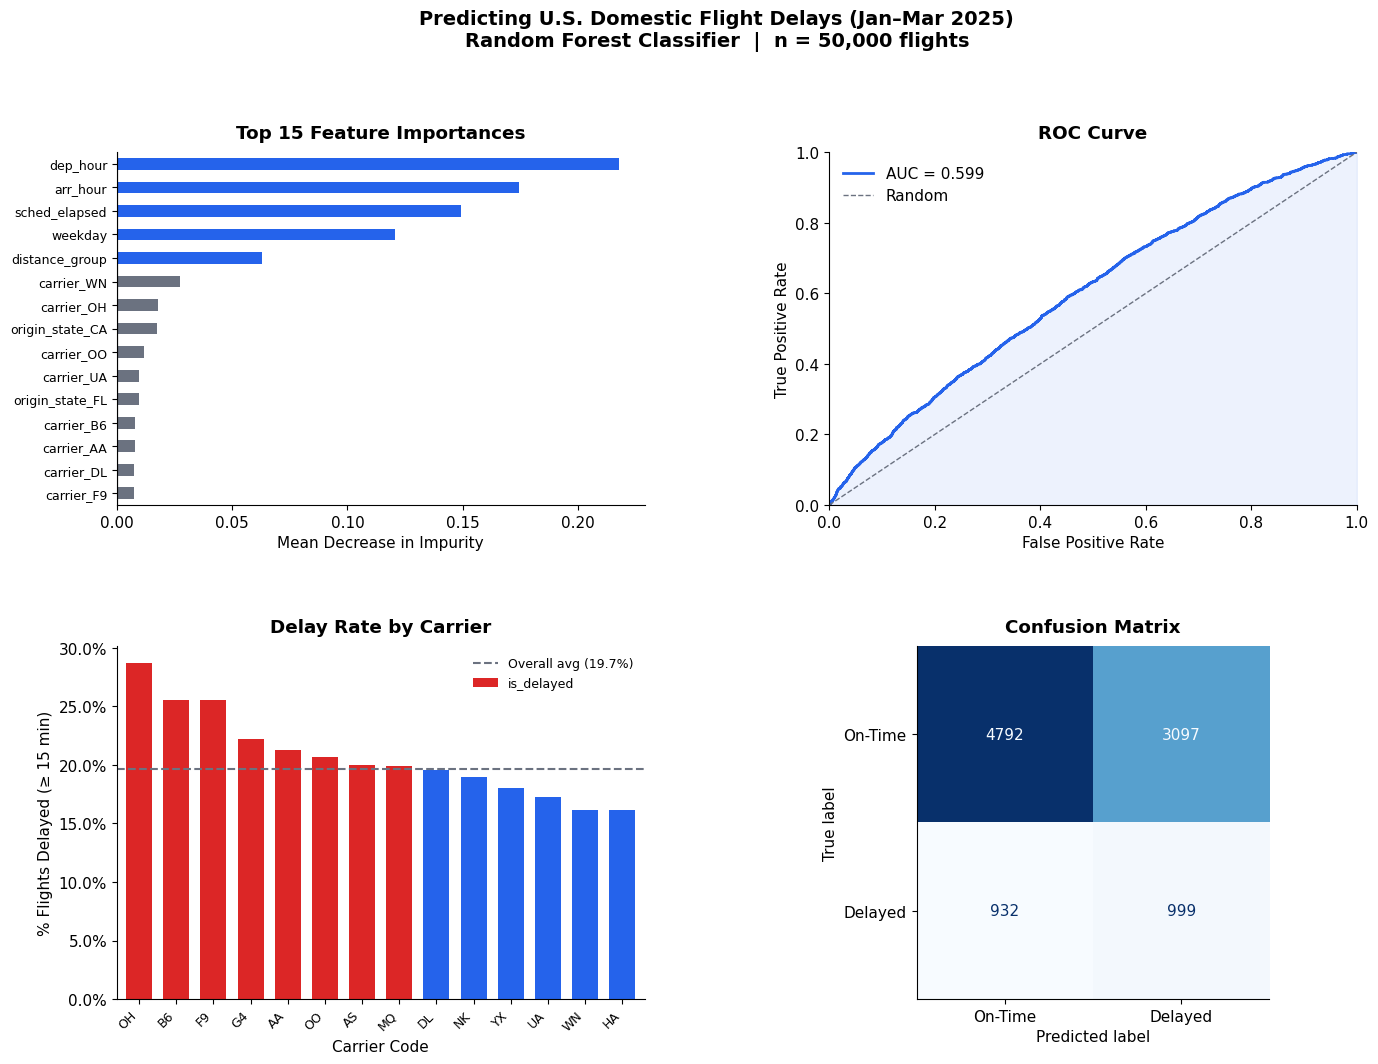

Figure saved to figures/delay_model_results.png


In [7]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve

matplotlib.rcParams.update({
    "font.family":  "DejaVu Sans",
    "font.size":    11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

ACCENT  = "#2563EB"   # blue
WARN    = "#DC2626"   # red
NEUTRAL = "#6B7280"   # grey

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

# feature importance
ax1 = fig.add_subplot(gs[0, 0])

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15).sort_values()

colors = [ACCENT if "carrier" not in i and "origin" not in i else NEUTRAL for i in top15.index]
top15.plot(kind="barh", ax=ax1, color=colors, edgecolor="none")
ax1.set_title("Top 15 Feature Importances", fontweight="bold", pad=10)
ax1.set_xlabel("Mean Decrease in Impurity")
ax1.tick_params(axis="y", labelsize=9)
ax1.axvline(0, color="black", linewidth=0.8)

# ROC curve
ax2 = fig.add_subplot(gs[0, 1])

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color=ACCENT, lw=2, label=f"AUC = {auc:.3f}")
ax2.plot([0, 1], [0, 1], color=NEUTRAL, lw=1, linestyle="--", label="Random")
ax2.fill_between(fpr, tpr, alpha=0.08, color=ACCENT)
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve", fontweight="bold", pad=10)
ax2.legend(frameon=False)
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)

# delay rate by carrier
ax3 = fig.add_subplot(gs[1, 0])

carrier_delay = (
    df.groupby("carrier")["is_delayed"]
    .mean()
    .sort_values(ascending=False)
)
bar_colors = [WARN if v > df["is_delayed"].mean() else ACCENT for v in carrier_delay]
carrier_delay.plot(kind="bar", ax=ax3, color=bar_colors, edgecolor="none", width=0.7)
ax3.axhline(df["is_delayed"].mean(), color=NEUTRAL, lw=1.5,
            linestyle="--", label=f"Overall avg ({df['is_delayed'].mean():.1%})")
ax3.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax3.set_title("Delay Rate by Carrier", fontweight="bold", pad=10)
ax3.set_xlabel("Carrier Code")
ax3.set_ylabel("% Flights Delayed (≥ 15 min)")
ax3.set_xticklabels(carrier_delay.index, rotation=45, ha="right", fontsize=9)
ax3.legend(frameon=False, fontsize=9)

# confusion matrix
ax4 = fig.add_subplot(gs[1, 1])

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On-Time", "Delayed"])
disp.plot(ax=ax4, colorbar=False, cmap="Blues")
ax4.set_title("Confusion Matrix", fontweight="bold", pad=10)

fig.suptitle(
    "Predicting U.S. Domestic Flight Delays (Jan–Mar 2025)\n"
    "Random Forest Classifier  |  n = 50,000 flights",
    fontsize=14, fontweight="bold", y=1.01
)

plt.savefig("../figures/delay_model_results.png", dpi=200,
            bbox_inches="tight", facecolor="white")
logger.info("Saved figures/delay_model_results.png")
plt.show()
print("Figure saved to figures/delay_model_results.png")


### Visualization Rationale

| Panel | Chart type | Why chosen |
|-------|-----------|------------|
| Feature Importance | Horizontal bar | Ordered importance values are most readable as horizontal bars; color distinguishes continuous vs. categorical-derived features |
| ROC Curve | Line + fill | Standard for binary classifiers; AUC summarises performance across all decision thresholds |
| Delay Rate by Carrier | Vertical bar | Aggregated proportions across 14 carriers; red/blue coloring immediately flags above/below-average performers |
| Confusion Matrix | Heatmap | Exposes the asymmetry between false positives and false negatives, critical for operational decision-making |

All panels share a consistent two-color palette (blue = neutral/good, red = alert) and
remove chart-junk spines to meet publication standards.

### Press Release Visualization: Best and Worst Times to Fly

This heatmap is designed for a general audience, it answers the traveler's question
directly: "When should I book to minimize my chance of a delay?"

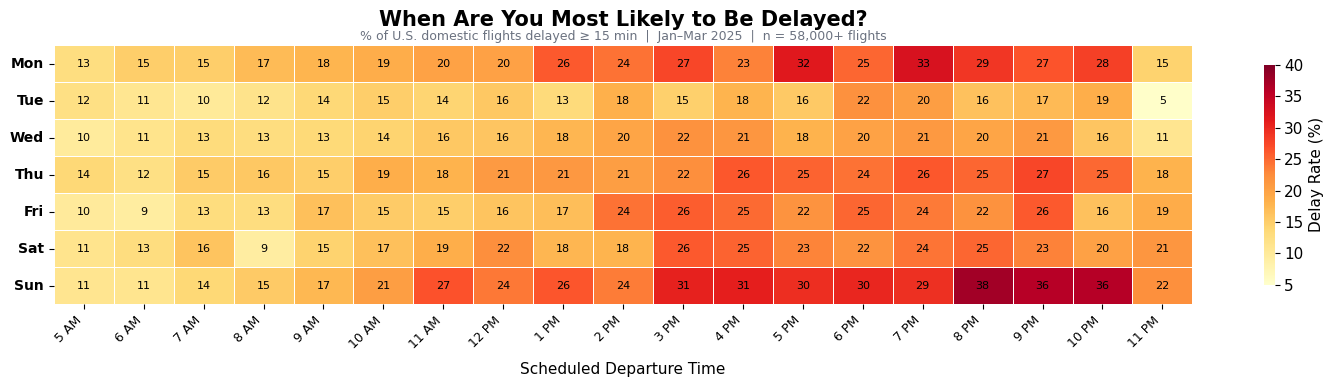

Saved → figures/best_times_to_fly.png


In [8]:
import seaborn as sns

DAY_LABELS = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}

# Only include hours that have at least 100 flights 
valid_hours = (
    df.groupby("dep_hour")["is_delayed"]
    .count()
    .pipe(lambda s: s[s >= 100].index)
)

pivot = (
    df[df["dep_hour"].isin(valid_hours)]
    .groupby(["weekday", "dep_hour"])["is_delayed"]
    .mean()
    .unstack("dep_hour")
    .mul(100)  # percentage
)
pivot.index = [DAY_LABELS[d] for d in pivot.index]

def hour_label(h):
    """Convert 24-hour int to readable AM/PM string."""
    if h == 0:  return "12 AM"
    if h < 12:  return f"{h} AM"
    if h == 12: return "12 PM"
    return f"{h - 12} PM"

col_labels = [hour_label(h) for h in pivot.columns]

fig, ax = plt.subplots(figsize=(15, 4))

sns.heatmap(
    pivot,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 8, "color": "black"},
    cbar_kws={"label": "Delay Rate (%)", "shrink": 0.85},
    vmin=5,
    vmax=40,
)

ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10, fontweight="bold")
ax.set_xlabel("Scheduled Departure Time", fontsize=11, labelpad=8)
ax.set_ylabel("")

ax.set_title(
    "When Are You Most Likely to Be Delayed?",
    fontsize=15, fontweight="bold", pad=14
)
fig.text(
    0.5, 1.01,
    "% of U.S. domestic flights delayed ≥ 15 min  |  Jan–Mar 2025  |  n = 58,000+ flights",
    ha="center", va="bottom", fontsize=9, color="#6B7280",
    transform=ax.transAxes
)

plt.tight_layout()
plt.savefig("../figures/best_times_to_fly.png", dpi=200,
            bbox_inches="tight", facecolor="white")
logger.info("Saved figures/best_times_to_fly.png")
plt.show()
print("Saved → figures/best_times_to_fly.png")
